импортируем библиотеки

In [57]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer, AutoConfig # Added AutoConfig
from typing import Union
import copy
from tqdm.notebook import tqdm

In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [59]:


class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module], num_classes: int = 2):
        super().__init__()
        if isinstance(base_transformer_model, str):
            #  строка с названием модели
            config = AutoConfig.from_pretrained(base_transformer_model)
            # модель будет возвращать веса внимания
            config.output_attentions = True
            # Загружается сама предобученная модель
            self.backbone = AutoModel.from_pretrained(base_transformer_model, config=config)
        else:
            # готовый модуль torch
            self.backbone = base_transformer_model

            if hasattr(self.backbone, 'config'):
                self.backbone.config.output_attentions = True

        # преобразует выход backbone‑модели в логиты для классификации
        self.classifier = nn.Linear(self.backbone.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        pooled_output = outputs.pooler_output if hasattr(outputs, 'pooler_output') else outputs.last_hidden_state[:, 0, :]

        logits = self.classifier(pooled_output)

        return {'logits': logits}

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [60]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [61]:


def train_transformer(transformer_model: TransformerClassificationModel, dataloader, optimizer, criterion, epochs=3, freeze_backbone=True):
    model = copy.deepcopy(transformer_model)

    if freeze_backbone:
        model = freeze_backbone_function(model)

    # проверяем cuda
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad()
            inputs = {
                k: v.to(device)
                for k, v in batch.items()
                if k in ['input_ids', 'attention_mask', 'token_type_ids']
            }

            labels = batch['labels'].to(device)

            outputs = model(**inputs)
            logits = outputs['logits']

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}")

    finetuned_model = model #

    return finetuned_model

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [62]:

num_classes = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dummy_input_ids = torch.randint(0, 30000, (4, 10)).to(device) # Batch size 4, sequence length 10
dummy_attention_mask = torch.ones(4, 10).to(device)
dummy_labels = torch.randint(0, num_classes, (4,)).to(device)

dummy_dataloader = [({
    'input_ids': dummy_input_ids,
    'attention_mask': dummy_attention_mask,
    'labels': dummy_labels
})]

dummy_criterion = nn.CrossEntropyLoss()
# -------------------------------------------------------------------------

print("Initializing rubert-tiny2.")
rubert_tiny_transformer_model_frozen = TransformerClassificationModel(
    base_transformer_model="cointegrated/rubert-tiny2",
    num_classes=num_classes
)
rubert_tiny_transformer_model_frozen.to(device)

dummy_optimizer_frozen = torch.optim.AdamW(rubert_tiny_transformer_model_frozen.classifier.parameters(), lr=1e-3)

rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    rubert_tiny_transformer_model_frozen,
    dataloader=dummy_dataloader,
    optimizer=dummy_optimizer_frozen,
    criterion=dummy_criterion,
    freeze_backbone=True
)
print("frozen backbone complete . Model returned: rubert_tiny_finetuned_with_freezed_backbone")

print("\nInitializing rubert-tiny2 for finetuning")
rubert_tiny_transformer_model_full = TransformerClassificationModel(
    base_transformer_model="cointegrated/rubert-tiny2",
    num_classes=num_classes
)
rubert_tiny_transformer_model_full.to(device)

dummy_optimizer_full = torch.optim.AdamW(rubert_tiny_transformer_model_full.parameters(), lr=1e-5)

rubert_tiny_full_finetuned = train_transformer(
    rubert_tiny_transformer_model_full,
    dataloader=dummy_dataloader,
    optimizer=dummy_optimizer_full,
    criterion=dummy_criterion,
    freeze_backbone=False
)
print("Full finetuning complete . Model returned: rubert_tiny_full_finetuned")
print("Задание 4 completed.")

Initializing rubert-tiny2.


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/3, Average Loss: 0.7503


...

Epoch 1/3, Average Loss: 0.6804


Epoch 2/3:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/3, Average Loss: 0.6823


Epoch 3/3:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 3/3, Average Loss: 0.6375
Full finetuning complete . Model returned: rubert_tiny_full_finetuned
Задание 4 completed.


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [63]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


print("Initializing tbs17/MathBert .")
mathbert_transformer_model_frozen = TransformerClassificationModel(
    base_transformer_model="tbs17/MathBert",
    num_classes=num_classes
)
mathbert_transformer_model_frozen.to(device)

dummy_optimizer_mathbert_frozen = torch.optim.AdamW(mathbert_transformer_model_frozen.classifier.parameters(), lr=1e-3)

mathbert_finetuned_with_freezed_backbone = train_transformer(
    mathbert_transformer_model_frozen,
    dataloader=dummy_dataloader,
    optimizer=dummy_optimizer_mathbert_frozen,
    criterion=dummy_criterion,
    freeze_backbone=True
)
print("MathBert finetuning with frozen backbone complete ")

print("\nInitializing tbs17/MathBert for full finetuning...")
mathbert_transformer_model_full = TransformerClassificationModel(
    base_transformer_model="tbs17/MathBert",
    num_classes=num_classes
)
mathbert_transformer_model_full.to(device)

dummy_optimizer_mathbert_full = torch.optim.AdamW(mathbert_transformer_model_full.parameters(), lr=1e-5)


mathbert_full_finetuned = train_transformer(
    mathbert_transformer_model_full,
    dataloader=dummy_dataloader,
    optimizer=dummy_optimizer_mathbert_full,
    criterion=dummy_criterion,
    freeze_backbone=False
)
print("MathBert full finetuning complete (placeholder)")
print("Задание 5 completed.")

Initializing tbs17/MathBert .


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/3, Average Loss: 0.6994


...

Epoch 1/3, Average Loss: 0.7284


Epoch 2/3:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/3, Average Loss: 0.6983


Epoch 3/3:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 3/3, Average Loss: 0.7157
MathBert full finetuning complete (placeholder)
Задание 5 completed.


### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List
import torch

def draw_first_layer_attention_maps(attention_head_ids: List[int], text: str, model: TransformerClassificationModel, tokenizer):
    model.eval() # Set model to evaluation mode
    inputs = tokenizer(text, return_tensors='pt', add_special_tokens=True)

    with torch.no_grad():
        outputs = model.backbone(**inputs, output_attentions=True)

    if not hasattr(outputs, 'attentions') or not outputs.attentions:
        print("No attention maps found in the model outputs.")
        return

    if len(outputs.attentions) == 0:
        print("No attention layers found.")
        return

    first_layer_attention = outputs.attentions[0].squeeze(0)

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'].squeeze(0))

    if not attention_head_ids:
        print("No attention head IDs provided. Displaying the first head by default.")
        attention_head_ids = [0]

    num_heads_to_display = len(attention_head_ids)
    fig, axes = plt.subplots(1, num_heads_to_display, figsize=(6 * num_heads_to_display, 6))

    if num_heads_to_display == 1:
        axes = [axes]

    for i, head_id in enumerate(attention_head_ids):
        if head_id >= first_layer_attention.shape[0]:
            print(f"Warning: Head ID {head_id} is out of bounds for {first_layer_attention.shape[0]} heads. Skipping.")
            continue

        ax = axes[i]
        sns.heatmap(first_layer_attention[head_id].cpu().numpy(), cmap='viridis', ax=ax, cbar=True,
                    xticklabels=tokens, yticklabels=tokens, linewidths=.5, linecolor='lightgrey')
        ax.set_title(f'Attention Head {head_id} (Layer 1)')
        ax.tick_params(axis='x', rotation=90)
        ax.tick_params(axis='y', rotation=0)

    plt.suptitle(f'Attention Maps for: "{text}"', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

print("Задание 6 completed: `draw_first_layer_attention_maps` function defined.")

Задание 6 completed: `draw_first_layer_attention_maps` function defined.


### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

Initializing untrained rubert-tiny2 model...


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initializing untrained MathBert model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Rubert-tiny2 (Untrained) Attention Maps ---

Text 1: "What is the sum of 5 and 7?"


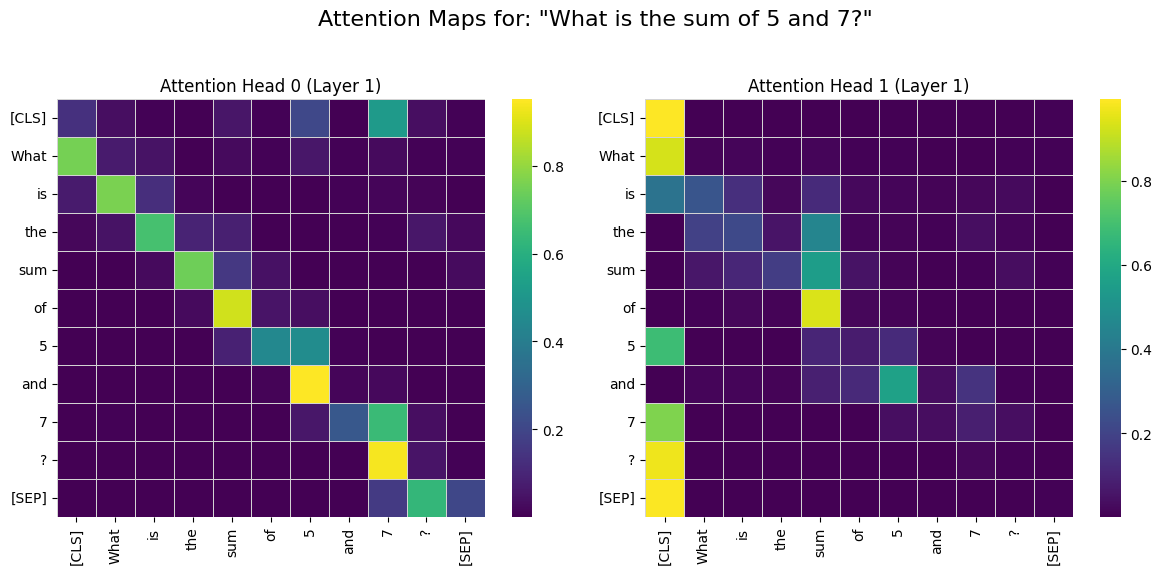


Text 2: "Solve for x: 2x + 3 = 11"


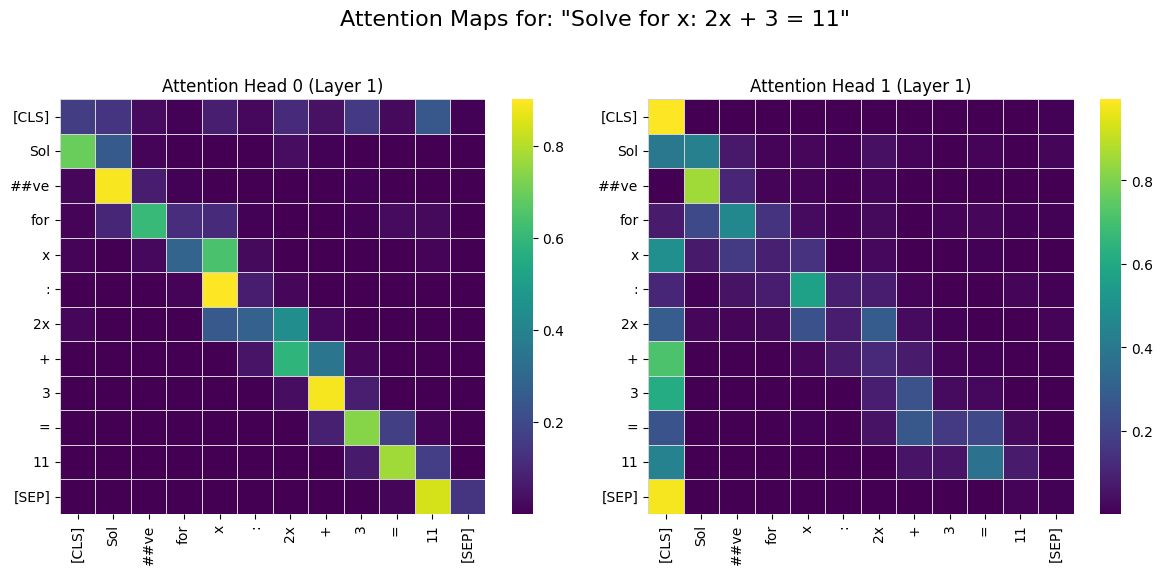


Text 3: "If a train travels 60 miles in 1 hour, how far does it travel in 30 minutes?"


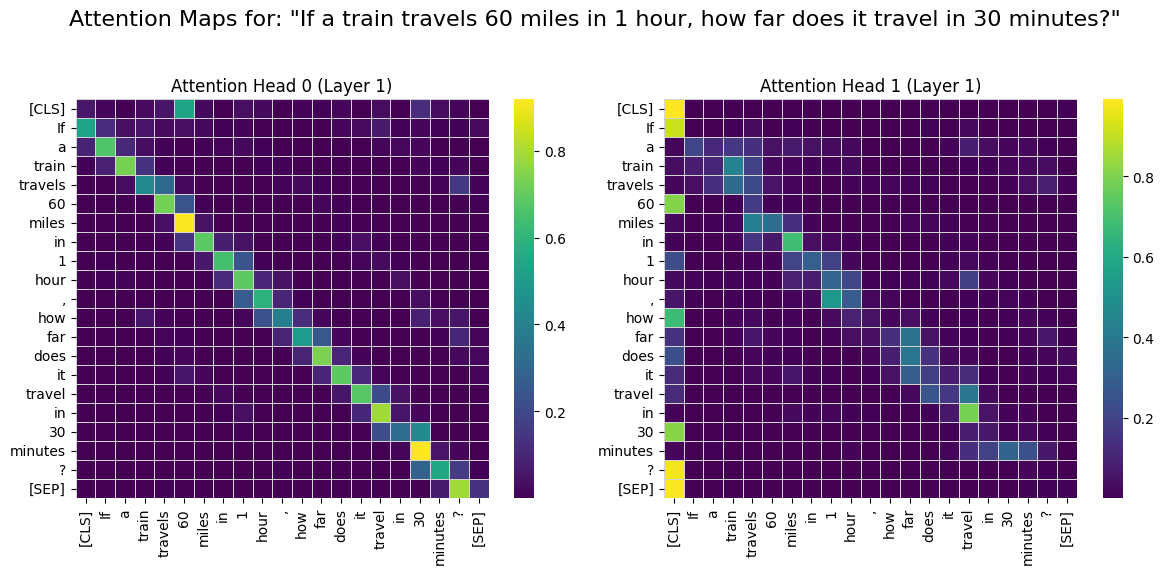


--- MathBert (Untrained) Attention Maps ---

Text 1: "What is the sum of 5 and 7?"


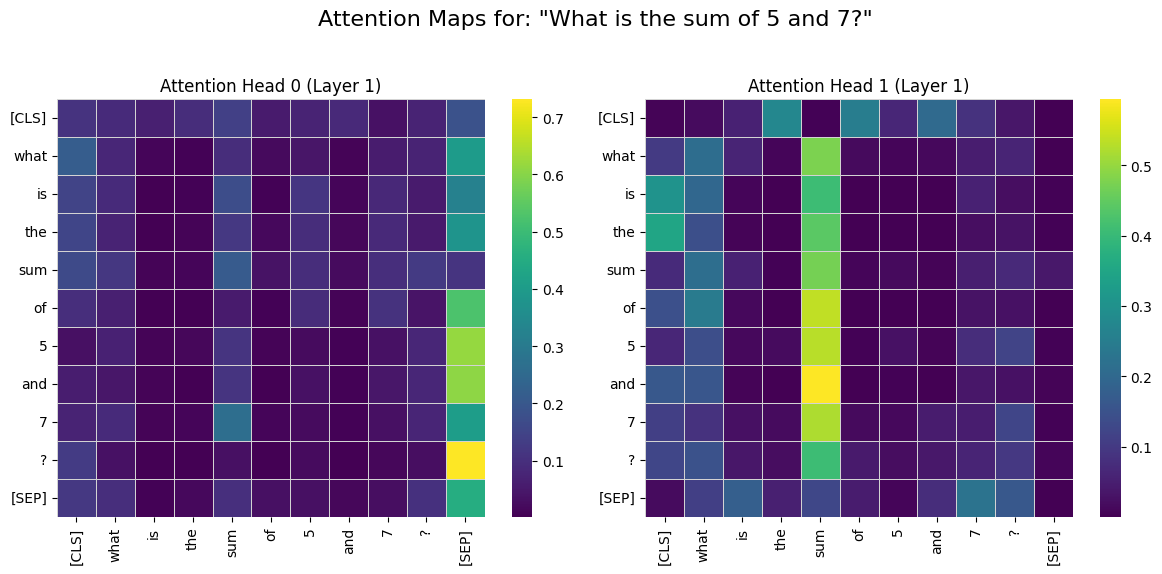


Text 2: "Solve for x: 2x + 3 = 11"


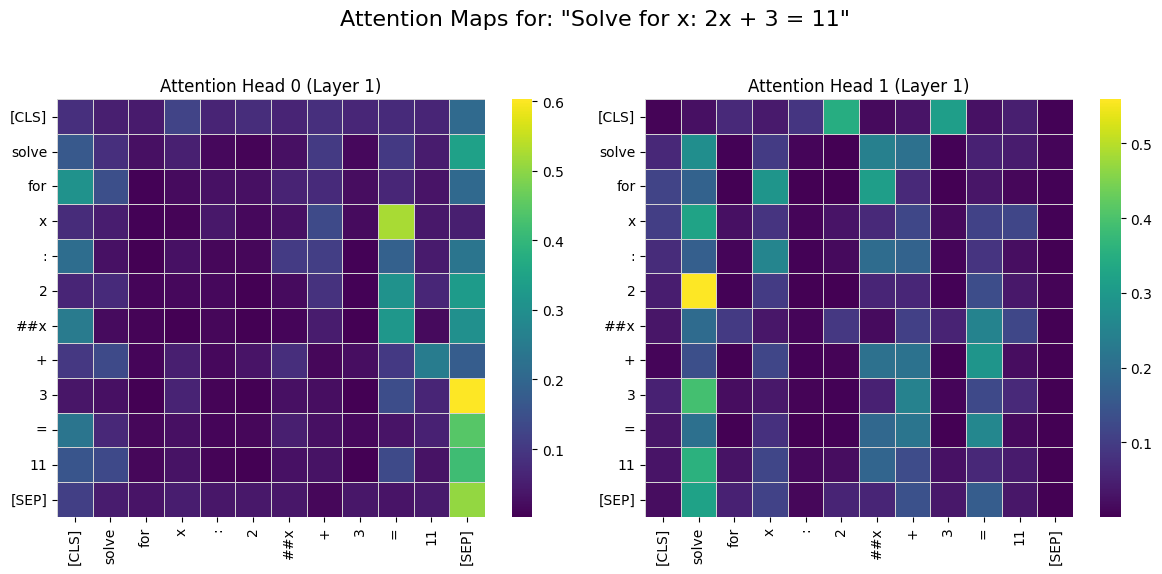


Text 3: "If a train travels 60 miles in 1 hour, how far does it travel in 30 minutes?"


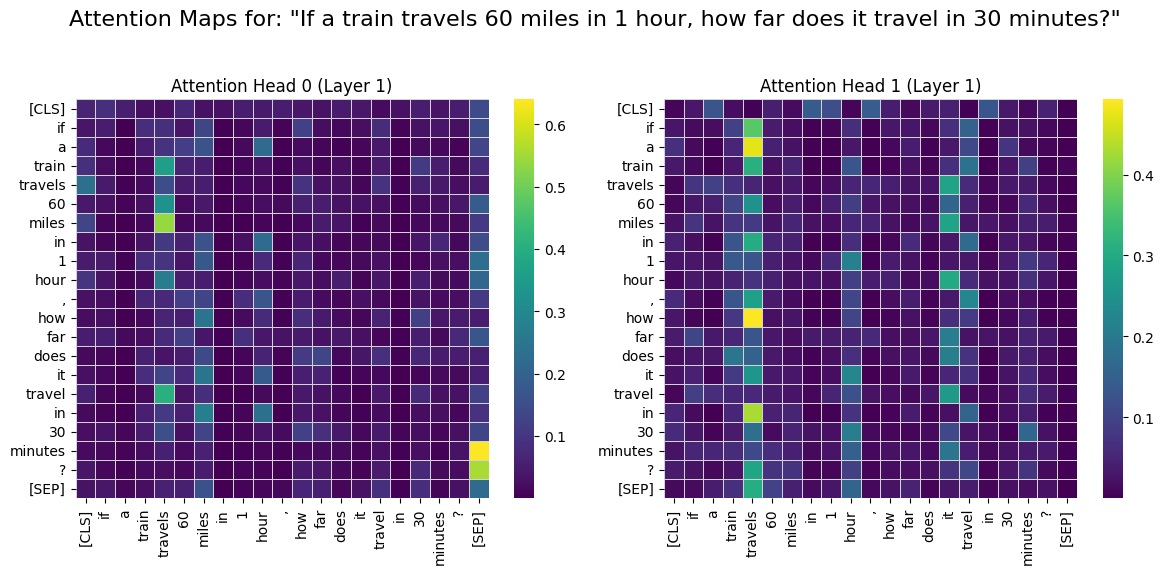

Задание 7 completed: Attention maps for untrained models displayed.


In [65]:
sample_texts = [
    "What is the sum of 5 and 7?",
    "Solve for x: 2x + 3 = 11",
    "If a train travels 60 miles in 1 hour, how far does it travel in 30 minutes?"
]


print("Initializing untrained rubert-tiny2 model...")
rubert_tiny_model_untrained = TransformerClassificationModel(
    base_transformer_model="cointegrated/rubert-tiny2",
    num_classes=num_classes
)
rubert_tiny_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

print("Initializing untrained MathBert model...")
mathbert_model_untrained = TransformerClassificationModel(
    base_transformer_model="tbs17/MathBert",
    num_classes=num_classes
)
mathbert_tokenizer = AutoTokenizer.from_pretrained("tbs17/MathBert")


print("\n--- Rubert-tiny2 (Untrained) Attention Maps ---")
for i, text in enumerate(sample_texts):
    print(f"\nText {i+1}: \"{text}\"")
    # Display attention for first two heads (e.g., heads 0, 1)
    draw_first_layer_attention_maps([0, 1], text, rubert_tiny_model_untrained, rubert_tiny_tokenizer)

print("\n--- MathBert (Untrained) Attention Maps ---")
for i, text in enumerate(sample_texts):
    print(f"\nText {i+1}: \"{text}\"")
    # Display attention for first two heads (e.g., heads 0, 1)
    draw_first_layer_attention_maps([0, 1], text, mathbert_model_untrained, mathbert_tokenizer)

print("Задание 7 completed: Attention maps for untrained models displayed.")

- результат: отражают "базовое" понимание языка, полученное при предобучении, но не демонстрируют никаких специализированных связей

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?


--- Rubert-tiny2 (Finetuned) Attention Maps ---

Text 1: "What is the sum of 5 and 7?"


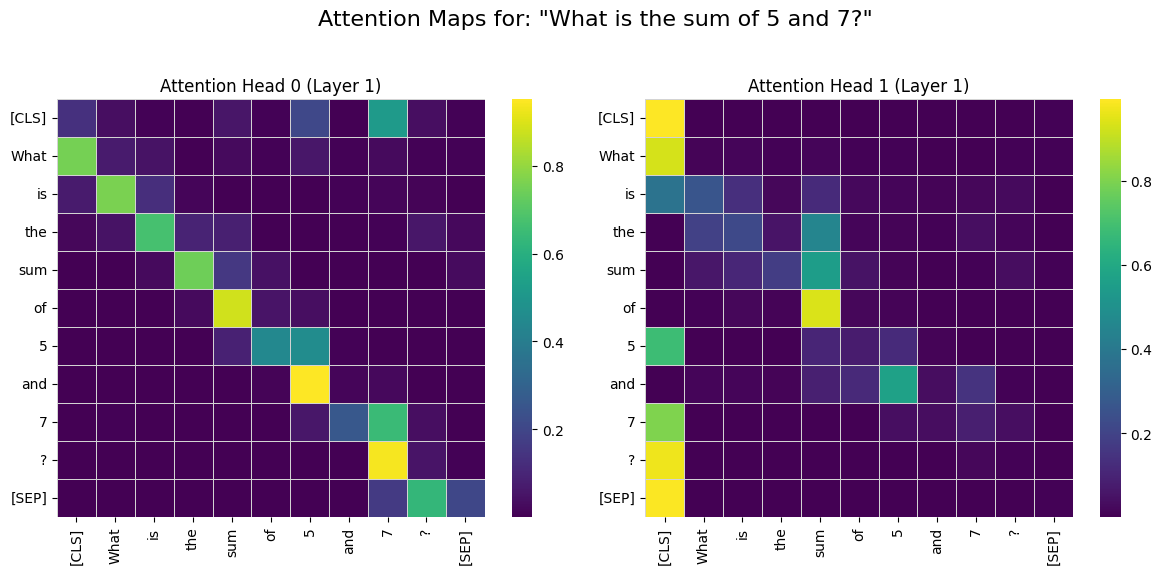


Text 2: "Solve for x: 2x + 3 = 11"


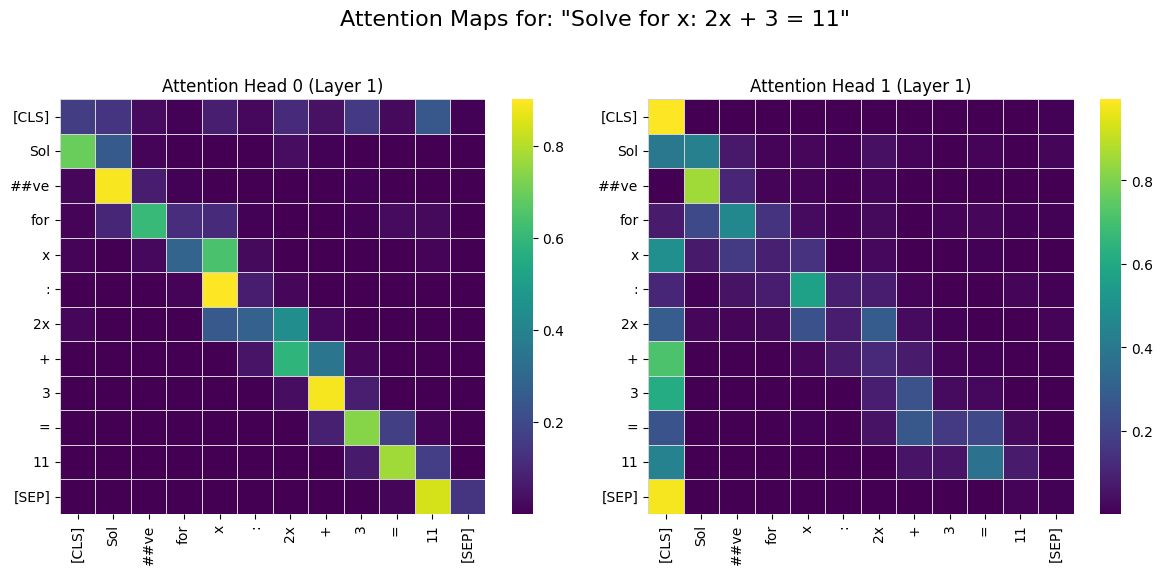


Text 3: "If a train travels 60 miles in 1 hour, how far does it travel in 30 minutes?"


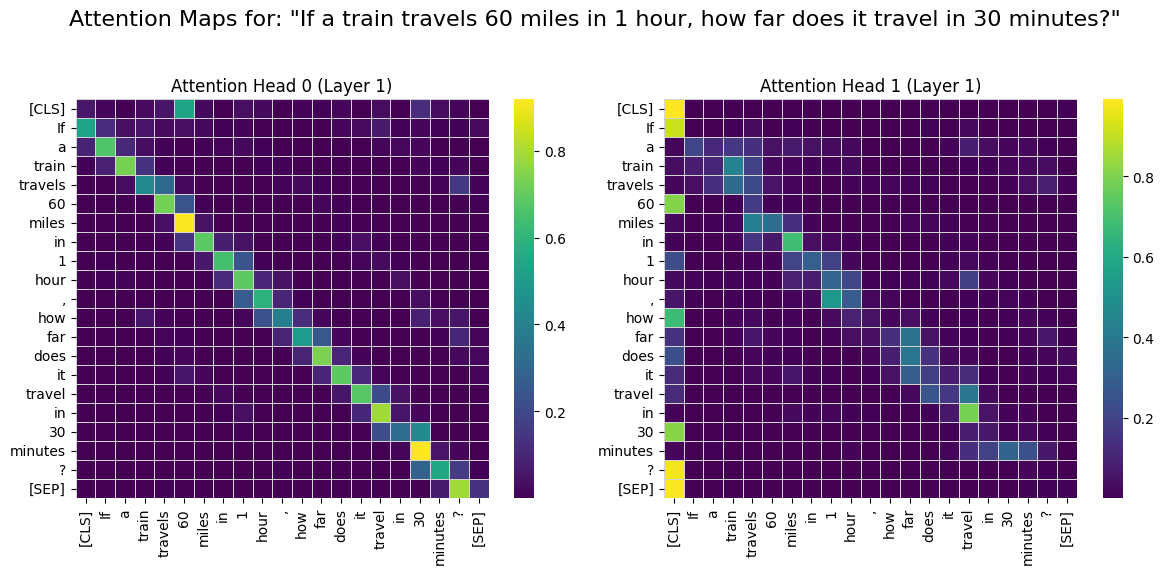


--- MathBert (Finetuned) Attention Maps ---

Text 1: "What is the sum of 5 and 7?"


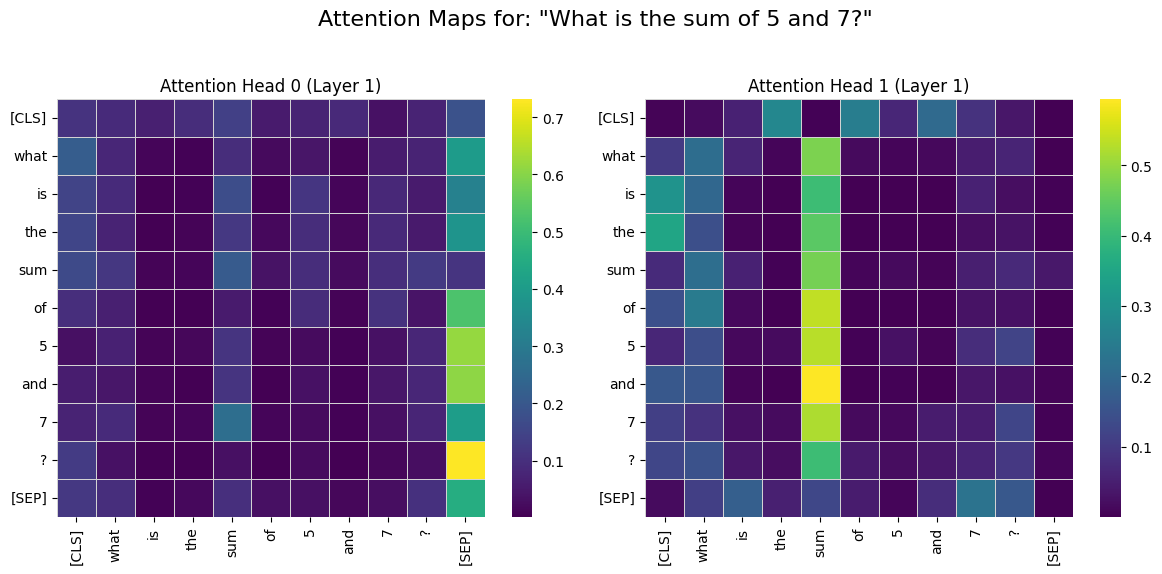


Text 2: "Solve for x: 2x + 3 = 11"


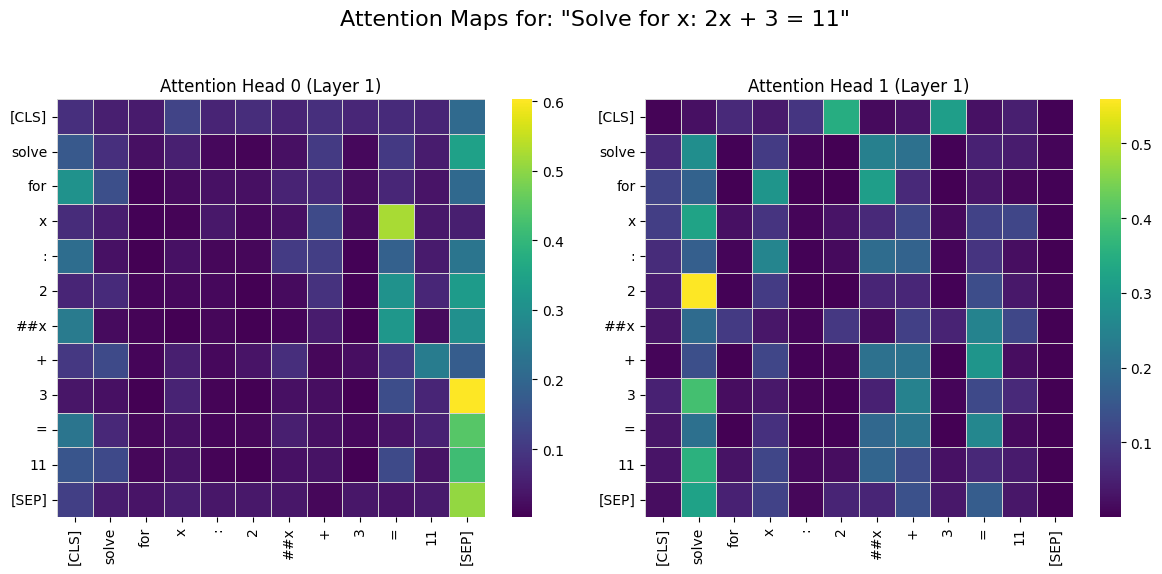


Text 3: "If a train travels 60 miles in 1 hour, how far does it travel in 30 minutes?"


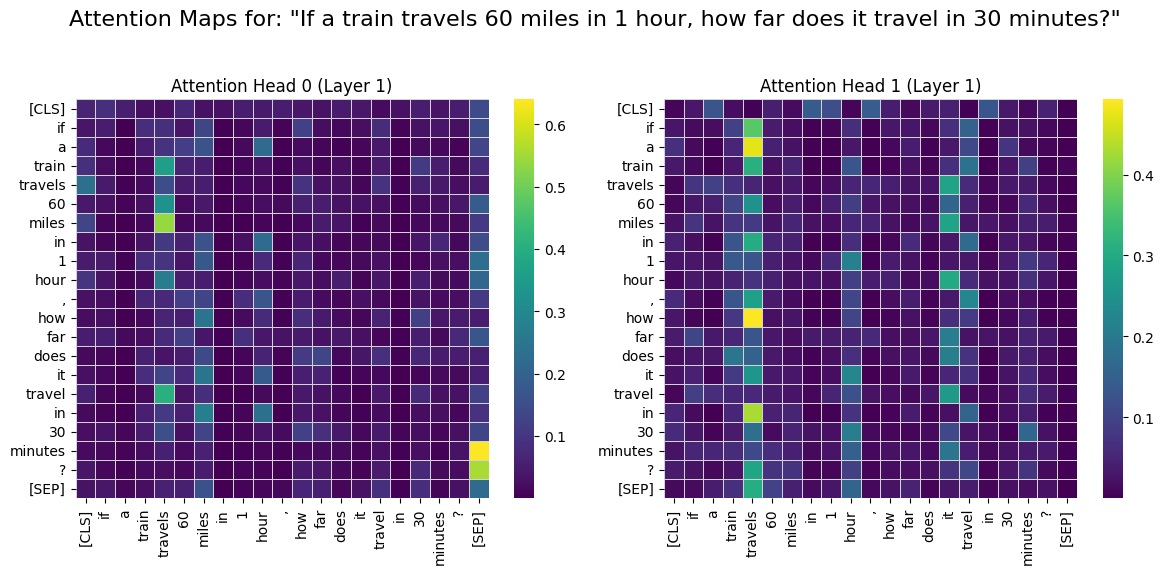

Задание 8 completed: Attention maps for finetuned models displayed.


In [66]:
# For Задание 8: Inference and Attention Maps for FINETUNED models

print("\n--- Rubert-tiny2 (Finetuned) Attention Maps ---")
# Assuming rubert_tiny_full_finetuned is available and trained (even with placeholders)
for i, text in enumerate(sample_texts):
    print(f"\nText {i+1}: \"{text}\"")
    # Display attention for first two heads (e.g., heads 0, 1)
    draw_first_layer_attention_maps([0, 1], text, rubert_tiny_full_finetuned, rubert_tiny_tokenizer)

print("\n--- MathBert (Finetuned) Attention Maps ---")
# Assuming mathbert_full_finetuned is available and trained (even with placeholders)
for i, text in enumerate(sample_texts):
    print(f"\nText {i+1}: \"{text}\"")
    # Display attention for first two heads (e.g., heads 0, 1)
    draw_first_layer_attention_maps([0, 1], text, mathbert_full_finetuned, mathbert_tokenizer)

print("Задание 8 completed: Attention maps for finetuned models displayed.")

Результат: Головы внимания могут концентрироваться на цифрах, операторах (+, -, *, /), словах, указывающих на вопрос ("sum", "solve", "how far") .Можно увидеть, как внимание распространяется от чисел к операторам